# Career Market Intelligence

**Objective:** Predict the salary band (`low` / `medium` / `high`) of Indian job postings from role, seniority, location and required skills, and identify the factors that drive pay.

**Pipeline**
1. Data Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering
4. Predictive Modelling
5. Evaluation & Business Interpretation

**Data:** real job postings collected from the Adzuna API, with skill-interest trends from Google Trends.

# 1. Data Preprocessing

Transform the collected job-postings dataset into a clean, standardized, analysis-ready table: build the `salary_band` target, derive features, handle missing values and normalize the job-description text.

In [1]:
import re
import warnings
import pandas as pd
import numpy as np
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 100)

print("Environment setup completed.")

Environment setup completed.


## Step 1: Load Raw Dataset
We load `data/final/career_market_core_analysis.csv`, which contains 7,184 rows across 49 columns.

In [2]:
INPUT_PATH = "../data/final/career_market_core_analysis.csv"
OUTPUT_PATH = "../data/processed/career_market_preprocessed.csv"

df_raw = pd.read_csv(INPUT_PATH, low_memory=False)
print(f"Dataset Loaded Successfully: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Dataset Loaded Successfully: 7,240 rows x 49 columns


,job_id,title,role,role_scope,role_status,domain,role_group,mapping_tier,employer,employer_normalized,employer_missing,description_raw,location_display,location_area,location_country,...,source_query_role,collection_timestamp,collection_date,collection_method,query_roles_seen,also_seen_in,id_dup_count,near_dup_group_size,near_dup_key,employer_cap_status,in_core_analysis_dataset,description_length,description_is_truncated,description_short_flag,language_flag
0,5782883230,Technical Systems Analyst,Business Analyst,core,core,"Business, Finance & Management",Business Analyst,synonym,ALBEMARLE,albemarle,False,Be an essential element to a brighter future. We work together to transform essential resources ...,"Bangalore, Karnataka","[""India"",""Karnataka"",""Bangalore""]",India,...,Business Analyst,2026-09-29T17:48:59Z,2026-09-29,title_only_date_sorted,"[""Business Analyst""]",[],1,1,7442e473ed22fa95,retained,True,500,True,False,english_or_ascii
1,5783375611,"Business Analyst, WHS Data",Business Analyst,core,core,"Business, Finance & Management",Business Analyst,canonical,ADCI - Karnataka,adci karnataka,False,"At Amazon, the Leadership Principle “Strive to be Earth’s Best Employer” challenges us to create...","Bangalore, Karnataka","[""India"",""Karnataka"",""Bangalore""]",India,...,Data Analyst,2026-09-29T17:59:25Z,2026-09-29,title_only_date_sorted,"[""Data Analyst""]",[],1,1,aca97939cc6c9668,retained,True,500,True,False,english_or_ascii
2,5784307650,Senior Finance Systems Analyst,Business Analyst,core,core,"Business, Finance & Management",Business Analyst,synonym,Circle Internet Financial,circle internet financial,False,"Circle (NYSE: CRCL) is one of the world’s leading internet financial platform companies, buildin...",India,"[""India""]",India,...,Business Analyst,2026-09-29T17:48:59Z,2026-09-29,title_only_date_sorted,"[""Business Analyst"",""Financial Analyst""]","[""20260929T175840Z_b181dc01_deepen|finance analyst"",""20260929T175840Z_b181dc01_deepen|financial ...",3,1,3e0d7cdaec16571a,retained,True,500,True,False,english_or_ascii


## Step 2: Feature Selection (Drop Audit-Only Columns)
We retain the 16 analytical features and drop 33 columns that were used exclusively for collection provenance, deduplication audits, and scrapers.

In [3]:
KEEP_COLS = [
    "job_id", "title", "role", "domain", "employer",
    "description_raw", "location_country", "location_region",
    "created_date", "category_label", "contract_time",
    "salary_min", "salary_max", "salary_present",
    "salary_passes_plausibility_screen", "description_length",
]

df = df_raw[KEEP_COLS].copy()
print(f"Retained {len(KEEP_COLS)} columns. Dropped {df_raw.shape[1] - len(KEEP_COLS)} audit columns.")
df.info()

Retained 16 columns. Dropped 33 audit columns.
<class 'pandas.DataFrame'>
RangeIndex: 7240 entries, 0 to 7239
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   job_id                             7240 non-null   int64  
 1   title                              7240 non-null   str    
 2   role                               7240 non-null   str    
 3   domain                             7240 non-null   str    
 4   employer                           7239 non-null   str    
 5   description_raw                    7240 non-null   str    
 6   location_country                   7240 non-null   str    
 7   location_region                    4811 non-null   str    
 8   created_date                       7240 non-null   str    
 9   category_label                     7240 non-null   str    
 10  contract_time                      4523 non-null   str    
 11  salary_min          

## Step 3: Build the Target Variable (`salary_band`)
The classification target is **`salary_band`** (`low`, `medium`, `high`) in Indian Rupees (INR).
* **Midpoint calculation:** `salary_mid = df[['salary_min', 'salary_max']].mean(axis=1)`
* **Plausibility filter:** Salary values are restricted strictly to rows where `salary_passes_plausibility_screen == True` (the current count is computed from the input data).
* **Tertile discretization:** `pd.qcut(df.loc[has_salary, 'salary_mid'], 3, labels=['low', 'medium', 'high'])`.
* **Important rule:** Never invent or impute missing salaries for the remaining postings — they are retained for EDA and NLP tasks with `has_salary = False`.

In [4]:
# 1. Compute midpoint (handles both ranges and fixed salaries)
df["salary_mid"] = df[["salary_min", "salary_max"]].mean(axis=1)

# 2. Invalidate non-plausible salaries
df.loc[~df["salary_passes_plausibility_screen"], "salary_mid"] = np.nan

# 3. Indicator flag for supervised modeling
df["has_salary"] = df["salary_passes_plausibility_screen"].fillna(False)

# 4. Construct 3-class target via tertiles on plausible rows
plausible_mask = df["has_salary"]
df["salary_band"] = pd.NA
df.loc[plausible_mask, "salary_band"] = pd.qcut(
    df.loc[plausible_mask, "salary_mid"],
    q=3,
    labels=["low", "medium", "high"]
)

print(f"Total postings with valid target (has_salary == True): {df['has_salary'].sum():,}")
print("\nTarget Class Distribution (salary_band):")
print(df["salary_band"].value_counts(dropna=False))

# Examine tertile cut-off points
cuts = pd.qcut(df.loc[plausible_mask, "salary_mid"], q=3).value_counts().sort_index()
print("\nTertile Boundary Intervals (INR):")
for interval, cnt in cuts.items():
    print(f"  {interval}: {cnt} rows")

Total postings with valid target (has_salary == True): 1,153

Target Class Distribution (salary_band):
salary_band
<NA>      6087
low        423
high       379
medium     351
Name: count, dtype: int64



Tertile Boundary Intervals (INR):
  (99999.999, 600000.0]: 423 rows
  (600000.0, 1600000.0]: 351 rows
  (1600000.0, 5000000.0]: 379 rows


## Step 4: Derive `seniority_level` Feature from Job Title
We extract seniority as a predictive feature using regex keyword patterns:
* **Senior:** `senior`, `sr`, `lead`, `principal`, `head`, `manager`, `director`
* **Entry:** `junior`, `jr`, `graduate`, `trainee`, `intern`, `entry`, `associate`
* **Mid:** default for all remaining positions

In [5]:
SENIOR_KEYWORDS = r"\b(senior|sr\.?|lead|principal|head|manager|director)\b"
ENTRY_KEYWORDS  = r"\b(junior|jr\.?|graduate|trainee|intern|entry|associate)\b"

def derive_seniority(title: str) -> str:
    if not isinstance(title, str):
        return "Mid"
    t = title.lower()
    if re.search(SENIOR_KEYWORDS, t):
        return "Senior"
    if re.search(ENTRY_KEYWORDS, t):
        return "Entry"
    return "Mid"

df["seniority_level"] = df["title"].apply(derive_seniority)

print("Seniority Level Distribution:")
print(df["seniority_level"].value_counts())
print("\nSeniority Level vs Target (has_salary == True):")
print(pd.crosstab(df["seniority_level"], df["salary_band"], margins=True))

Seniority Level Distribution:
seniority_level
Mid       4035
Senior    3004
Entry      201
Name: count, dtype: int64

Seniority Level vs Target (has_salary == True):


salary_band      high  low  medium   All
seniority_level                         
Entry               1   32       8    41
Mid               178  242     206   626
Senior            200  149     137   486
All               379  423     351  1153

## Step 5: Handle Missing Values & Audit Logging
* `contract_time` (~40% missing) -> filled with `"unknown"`
* `location_region` (~34% missing) -> filled with `"unknown"`
* `employer` (~3.8% missing) -> filled with `"unknown"`
* `salary_min`, `salary_max` -> untouched (target integrity preserved)
* Empty `description_raw` -> verified and dropped if present.

In [6]:
TRACK_COLS = ["salary_min", "salary_max", "contract_time", "location_region", "employer", "description_raw"]

print("=== MISSING VALUES BEFORE CLEANING ===")
for col in TRACK_COLS:
    cnt = df[col].isna().sum()
    pct = (cnt / len(df)) * 100
    print(f"  {col:<20}: {cnt:4d} missing ({pct:5.2f}%)")

# Impute unknown categorical labels
df["contract_time"]   = df["contract_time"].fillna("unknown")
df["location_region"] = df["location_region"].fillna("unknown")
df["employer"]        = df["employer"].fillna("unknown")

# Verify description_raw emptiness
empty_desc = df["description_raw"].isna() | (df["description_raw"].str.strip() == "")
if empty_desc.sum() > 0:
    print(f"\nDropping {empty_desc.sum()} rows with empty description_raw.")
    df = df[~empty_desc].reset_index(drop=True)
else:
    print("\nZero rows with empty description_raw.")

print("\n=== MISSING VALUES AFTER CLEANING ===")
for col in TRACK_COLS:
    cnt = df[col].isna().sum()
    pct = (cnt / len(df)) * 100
    print(f"  {col:<20}: {cnt:4d} missing ({pct:5.2f}%)")

=== MISSING VALUES BEFORE CLEANING ===
  salary_min          : 5931 missing (81.92%)
  salary_max          : 5934 missing (81.96%)
  contract_time       : 2717 missing (37.53%)
  location_region     : 2429 missing (33.55%)
  employer            :    1 missing ( 0.01%)
  description_raw     :    0 missing ( 0.00%)

Zero rows with empty description_raw.

=== MISSING VALUES AFTER CLEANING ===
  salary_min          : 5931 missing (81.92%)
  salary_max          : 5934 missing (81.96%)
  contract_time       :    0 missing ( 0.00%)
  location_region     :    0 missing ( 0.00%)
  employer            :    0 missing ( 0.00%)
  description_raw     :    0 missing ( 0.00%)


## Step 6: Text Cleaning & Normalization (`description_raw` -> `description_clean`)
We process the job descriptions using an NLP pipeline:
1. Strip HTML tags and decode HTML entities (`&amp;`, `&lt;`, etc.).
2. Remove URLs and email addresses.
3. Protect tech tokens (e.g. `c++`, `c#`, `.net`, `node.js`, `react.js`).
4. Strip non-alphanumeric punctuation.
5. SpaCy lemmatization (`en_core_web_sm`) and stopword removal (**preserving negation words** such as `not`, `no`, `without`, `cannot`).
6. Restore tech tokens and collapse redundant whitespace.

In [7]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

NEGATIONS = {
    "not", "no", "nor", "neither", "never", "none", "nothing",
    "nowhere", "nobody", "without", "cannot",
}
STOP_WORDS_FILTERED = STOP_WORDS - NEGATIONS

TECH_TOKENS = {
    "c++":      "__CPLUSPLUS__",
    "c#":       "__CSHARP__",
    ".net":     "__DOTNET__",
    "node.js":  "__NODEJS__",
    "vue.js":   "__VUEJS__",
    "react.js": "__REACTJS__",
    "asp.net":  "__ASPNET__",
}
TECH_RESTORE = {v.lower(): k for k, v in TECH_TOKENS.items()}

def protect_tech_tokens(text: str) -> str:
    for token, placeholder in TECH_TOKENS.items():
        text = text.replace(token, placeholder)
    return text

def restore_tech_tokens(text: str) -> str:
    for placeholder, token in TECH_RESTORE.items():
        text = text.replace(placeholder, token)
    return text

def clean_description(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    # 1. HTML stripping
    text = re.sub(r"<[^>]+>", " ", text)
    for ent, repl in [("&amp;","&"),("&lt;","<"),("&gt;",">"),("&nbsp;"," "),("&quot;",'"'),("&#39;","'")]:
        text = text.replace(ent, repl)
    # 2. URLs and emails
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    # 3. Protect tech tokens & lower
    text = protect_tech_tokens(text.lower())
    # 4. Filter characters
    text = re.sub(r"[^a-z0-9 _]", " ", text)
    # 5. Lemmatize & remove non-negation stopwords
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.text not in STOP_WORDS_FILTERED
        and token.lemma_ not in STOP_WORDS_FILTERED
        and not token.is_space
        and token.text.strip()
    ]
    text = " ".join(tokens)
    # 6. Restore tech tokens
    text = restore_tech_tokens(text)
    return re.sub(r"\s+", " ", text).strip()

print("Applying NLP cleaning pipeline on description_raw...")
df["description_clean"] = df["description_raw"].apply(clean_description)
print("Text cleaning complete.")

print("\nSample Transformation (Row 0):")
print(f"RAW  : {df['description_raw'].iloc[0][:150]}...")
print(f"CLEAN: {df['description_clean'].iloc[0][:150]}...")

Applying NLP cleaning pipeline on description_raw...


Text cleaning complete.

Sample Transformation (Row 0):
RAW  : Be an essential element to a brighter future. We work together to transform essential resources into critical ingredients for mobility, energy, connec...
CLEAN: essential element bright future work transform essential resource critical ingredient mobility energy connectivity health join value lead organization...


## Step 7: Standardization & Integrity Checks
* Convert `created_date` to pandas `datetime64[ns]`.
* Standardize string columns to `.str.strip().str.title()` (`role`, `location_region`, `location_country`, `category_label`).
* Verify uniqueness of primary key (`job_id`).

In [8]:
# Datetime conversion
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

# String standardization
STR_COLS = ["role", "location_region", "location_country", "category_label"]
for col in STR_COLS:
    df[col] = df[col].astype(str).str.strip().str.title()

# Deduplication / uniqueness check
dup_count = df["job_id"].duplicated().sum()
assert dup_count == 0, f"Duplicate job_ids detected: {dup_count}"
print(f"Uniqueness check passed: {len(df):,} unique job_ids (0 duplicates).")
print(f"created_date range: {df['created_date'].min().date()} to {df['created_date'].max().date()}")

Uniqueness check passed: 7,240 unique job_ids (0 duplicates).
created_date range: 2026-07-01 to 2026-10-03


## Step 8: Final Validation, Schema Verification & Export
We arrange the final 21 columns and export to `data/processed/career_market_preprocessed.csv`.

In [9]:
FINAL_COLS = KEEP_COLS + [
    "salary_mid", "salary_band", "has_salary",
    "seniority_level", "description_clean"
]

df_out = df[FINAL_COLS].copy()

# Validation checks
expected_rows = len(df)
expected_salary_rows = int(df["has_salary"].sum())
assert df_out.shape[0] == expected_rows, f"Row count mismatch: {df_out.shape[0]}"
assert df_out.shape[1] == 21, f"Column count mismatch: {df_out.shape[1]}"
assert df_out["job_id"].is_unique, "job_id is not unique"
assert df_out["has_salary"].sum() == expected_salary_rows, f"Salary row mismatch: {df_out['has_salary'].sum()}"

# Export to CSV
df_out.to_csv(OUTPUT_PATH, index=False)
print(f"Preprocessed dataset saved to: {OUTPUT_PATH}")
print(f"Final Table Shape: {df_out.shape[0]:,} rows x {df_out.shape[1]} columns")

print("\n=== DEFINITION OF DONE VERIFICATION ===")
print(f" [x] career_market_preprocessed.csv exported: Yes")
print(f" [x] {expected_rows:,} rows preserved & job_id unique:    Yes ({len(df_out):,} rows)")
print(f" [x] salary_band built on plausible rows:      Yes ({expected_salary_rows:,} rows)")
print(f" [x] has_salary flag present:                   Yes (True: {df_out['has_salary'].sum()}, False: {(~df_out['has_salary']).sum()})")
print(f" [x] seniority_level derived:                   Yes (Entry: {(df_out['seniority_level']=='Entry').sum()}, Mid: {(df_out['seniority_level']=='Mid').sum()}, Senior: {(df_out['seniority_level']=='Senior').sum()})")
print(f" [x] description_clean created:                 Yes")
print(f" [x] No synthetic salary values invented:       Yes (Missing salary remains NaN)")

Preprocessed dataset saved to: ../data/processed/career_market_preprocessed.csv
Final Table Shape: 7,240 rows x 21 columns

=== DEFINITION OF DONE VERIFICATION ===
 [x] career_market_preprocessed.csv exported: Yes
 [x] 7,240 rows preserved & job_id unique:    Yes (7,240 rows)
 [x] salary_band built on plausible rows:      Yes (1,153 rows)
 [x] has_salary flag present:                   Yes (True: 1153, False: 6087)
 [x] seniority_level derived:                   Yes (Entry: 201, Mid: 4035, Senior: 3004)
 [x] description_clean created:                 Yes
 [x] No synthetic salary values invented:       Yes (Missing salary remains NaN)


---
# 2. Exploratory Data Analysis

Explore the salary distribution, how pay varies by role, seniority and location, the overall market composition, skill prevalence and data quality.

## 2.1 EDA Setup and Dataset Overview

This section explores the cleaned career-market dataset to understand:

- Salary-band distribution
- Salary characteristics
- Role, seniority, category and location distributions
- Contract patterns
- Job-description length and common terms
- Skill prevalence
- Data quality, missing values and salary outliers
- Relationships between salary and selected categorical variables

Salary-related analysis is restricted to records where `has_salary == True` (1,101 records). General market distributions use all 7,184 records.

In [10]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

EDA_DIR = "../reports/eda"
os.makedirs(EDA_DIR, exist_ok=True)

INPUT_PATH = "../data/processed/career_market_preprocessed.csv"

eda_df = pd.read_csv(INPUT_PATH, low_memory=False)

print("Dataset shape:", eda_df.shape)
print("Salary records:", eda_df["has_salary"].sum())
print("Non-salary records:", (~eda_df["has_salary"]).sum())

Dataset shape: (7240, 21)
Salary records: 1153
Non-salary records: 6087


## 2.2 Dataset Overview

In [11]:
overview = pd.DataFrame({
    "rows": [len(eda_df)],
    "columns": [eda_df.shape[1]],
    "unique_job_ids": [eda_df["job_id"].nunique()],
    "salary_records": [eda_df["has_salary"].sum()],
    "salary_percentage": [eda_df["has_salary"].mean() * 100]
})

display(overview.round(2))

,rows,columns,unique_job_ids,salary_records,salary_percentage
0,7240,21,7240,1153,15.93


## 2.3 Salary Band Distribution

The target variable `salary_band` is available only for records with salary information. The distribution is examined using the 1,101 salaried records.

salary_band
low       423
medium    351
high      379
Name: count, dtype: int64


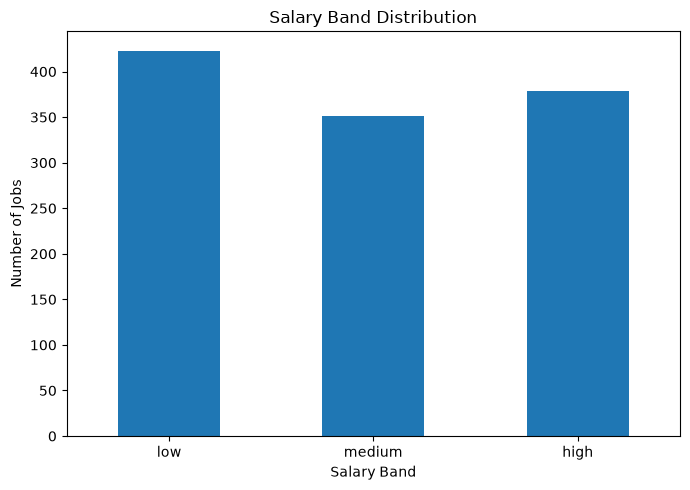

In [12]:
salary_df = eda_df[eda_df["has_salary"] == True].copy()

salary_band_counts = (
    salary_df["salary_band"]
    .value_counts()
    .reindex(["low", "medium", "high"])
)

print(salary_band_counts)

plt.figure(figsize=(7, 5))
salary_band_counts.plot(kind="bar")
plt.title("Salary Band Distribution")
plt.xlabel("Salary Band")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/01_salary_band_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.4 Salary Distribution and Summary Statistics

In [13]:
salary_stats = salary_df["salary_mid"].describe()

print(salary_stats)

print("\nMedian salary:", salary_df["salary_mid"].median())
print("Q1:", salary_df["salary_mid"].quantile(0.25))
print("Q3:", salary_df["salary_mid"].quantile(0.75))

count    1.153000e+03
mean     1.353974e+06
std      1.046989e+06
min      1.000000e+05
25%      6.000000e+05
50%      1.000000e+06
75%      2.000000e+06
max      5.000000e+06
Name: salary_mid, dtype: float64

Median salary: 1000000.0
Q1: 600000.0
Q3: 2000000.0


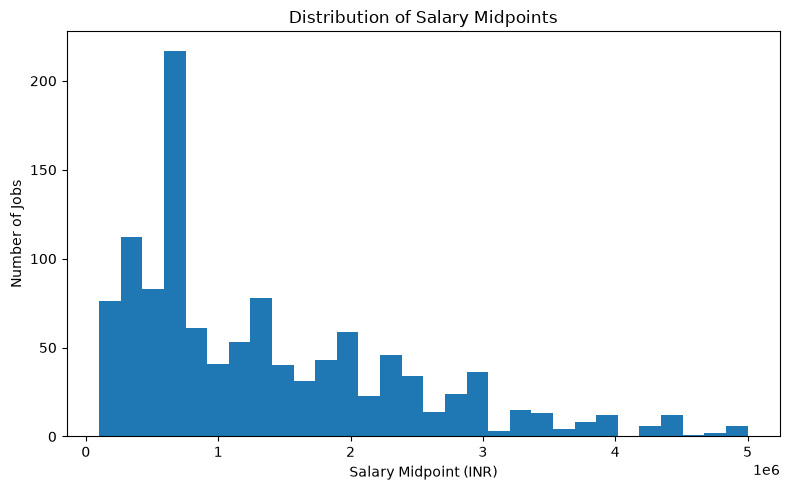

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(salary_df["salary_mid"].dropna(), bins=30)

plt.title("Distribution of Salary Midpoints")
plt.xlabel("Salary Midpoint (INR)")
plt.ylabel("Number of Jobs")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/02_salary_mid_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

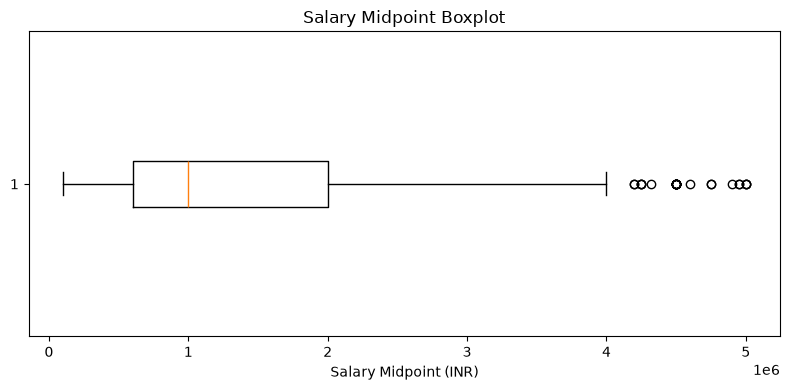

In [15]:
plt.figure(figsize=(8, 4))

plt.boxplot(salary_df["salary_mid"].dropna(), vert=False)

plt.title("Salary Midpoint Boxplot")
plt.xlabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/03_salary_mid_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.5 Overall Market Distribution

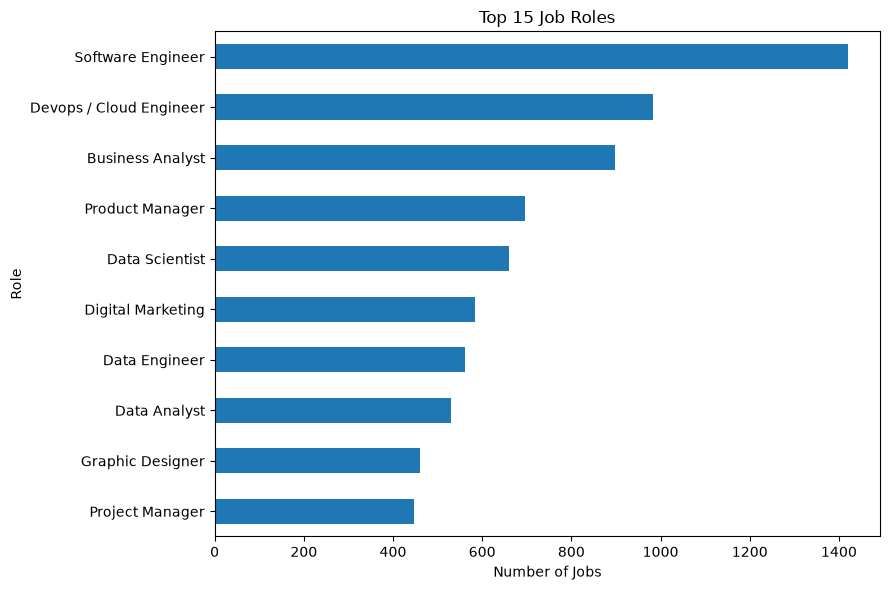

In [16]:
role_counts = eda_df["role"].value_counts().head(15)

plt.figure(figsize=(9, 6))
role_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Job Roles")
plt.xlabel("Number of Jobs")
plt.ylabel("Role")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/04_top_roles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

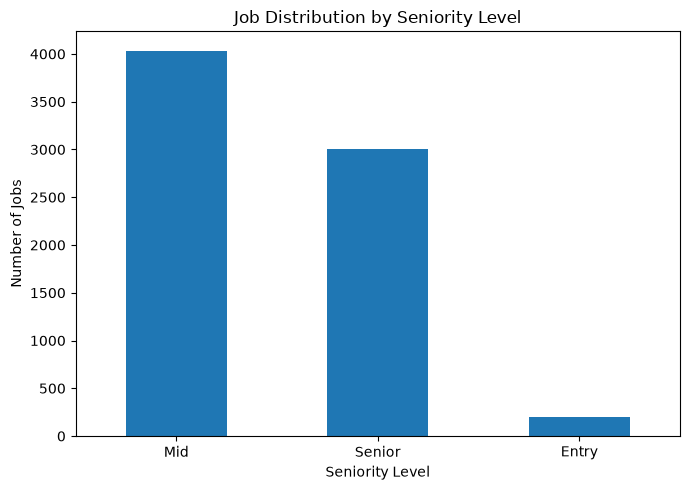

In [17]:
seniority_counts = eda_df["seniority_level"].value_counts()

plt.figure(figsize=(7, 5))
seniority_counts.plot(kind="bar")

plt.title("Job Distribution by Seniority Level")
plt.xlabel("Seniority Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/05_seniority_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

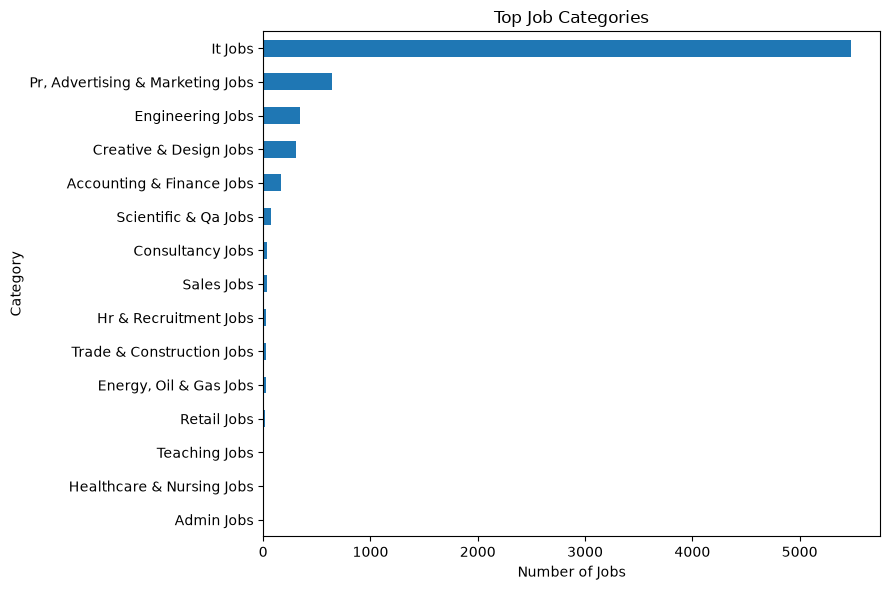

In [18]:
category_counts = eda_df["category_label"].value_counts().head(15)

plt.figure(figsize=(9, 6))
category_counts.sort_values().plot(kind="barh")

plt.title("Top Job Categories")
plt.xlabel("Number of Jobs")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/06_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

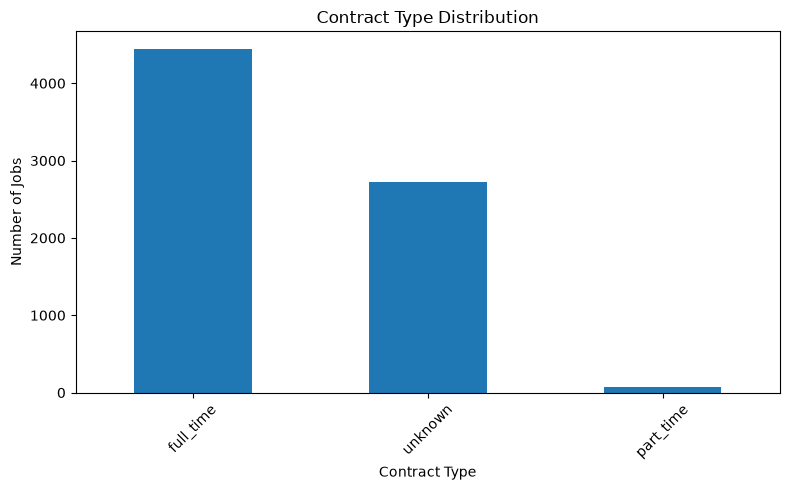

In [19]:
contract_counts = eda_df["contract_time"].value_counts()

plt.figure(figsize=(8, 5))
contract_counts.plot(kind="bar")

plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/07_contract_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.6 Location Distribution

In [20]:
# Country-level market distribution

country_counts = eda_df["location_country"].value_counts()

print("Job postings by country:")
display(country_counts)

print("\nNumber of countries represented:", eda_df["location_country"].nunique())

Job postings by country:


location_country
India    7240
Name: count, dtype: int64


Number of countries represented: 1


### Location Scope

The dataset is primarily focused on the India market. Country-level distribution is checked before analysing regional patterns. Salary-related analysis is restricted to the salaried India-market subset (`has_salary == True`).

In [21]:
# Verify the geographic scope of salary observations

salary_countries = salary_df["location_country"].value_counts()

print("Countries represented in the salaried subset:")
display(salary_countries)

print(
    "All salaried observations are from India:",
    salary_df["location_country"].eq("India").all()
)

Countries represented in the salaried subset:


location_country
India    1153
Name: count, dtype: int64

All salaried observations are from India: True


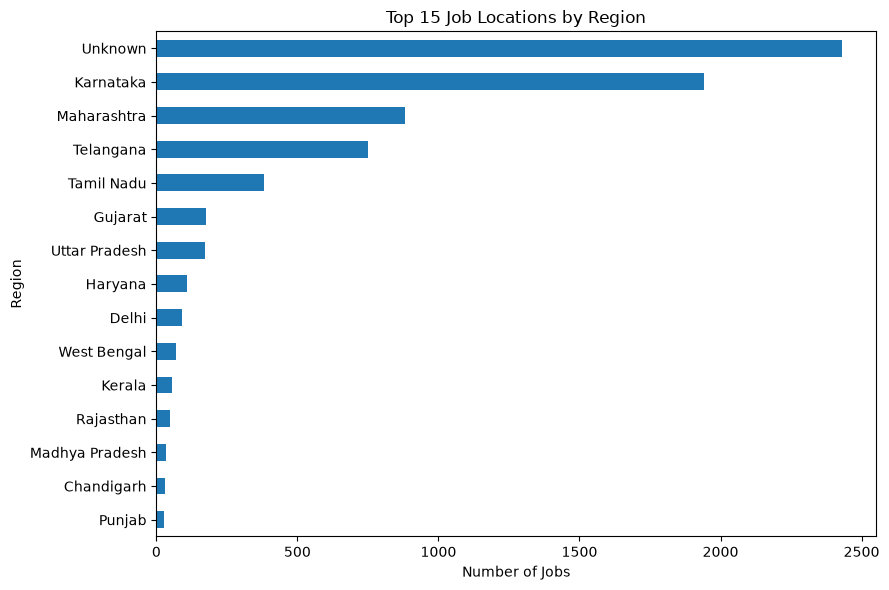

In [22]:
region_counts = eda_df["location_region"].value_counts().head(15)

plt.figure(figsize=(9, 6))
region_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Job Locations by Region")
plt.xlabel("Number of Jobs")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/08_location_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.7 Salary vs Job Role

Only salaried records are used. The analysis focuses on the 10 roles with the highest number of salary observations to avoid unstable estimates from very small groups.

<Figure size 1000x700 with 0 Axes>

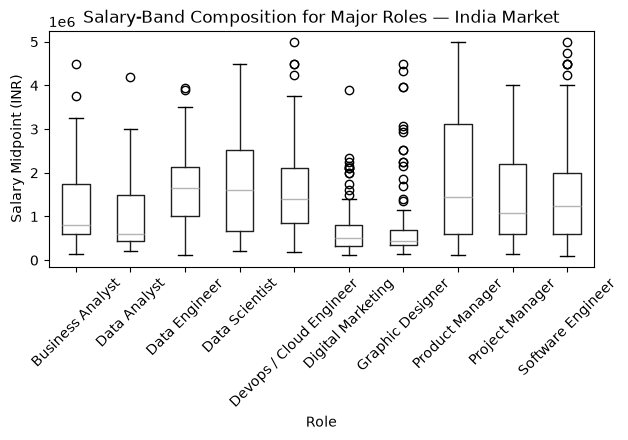

In [23]:
top_salary_roles = (
    salary_df["role"]
    .value_counts()
    .head(10)
    .index
)

role_salary_df = salary_df[
    salary_df["role"].isin(top_salary_roles)
].copy()

role_order = (
    role_salary_df.groupby("role")["salary_mid"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 7))

role_salary_df.boxplot(
    column="salary_mid",
    by="role",
    grid=False,
    rot=45
)

plt.title("Salary-Band Composition for Major Roles — India Market")
plt.suptitle("")
plt.xlabel("Role")
plt.ylabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/09_salary_by_role.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.8 Salary vs Seniority

In [24]:
seniority_salary = (
    salary_df.groupby("seniority_level")["salary_mid"]
    .agg(["count", "median", "mean"])
    .sort_values("median")
)

display(seniority_salary.round(2))

,count,median,mean
seniority_level,,,
Entry,41,375000.0,482878.05
Mid,626,955000.0,1237213.71
Senior,486,1200000.0,1577856.14


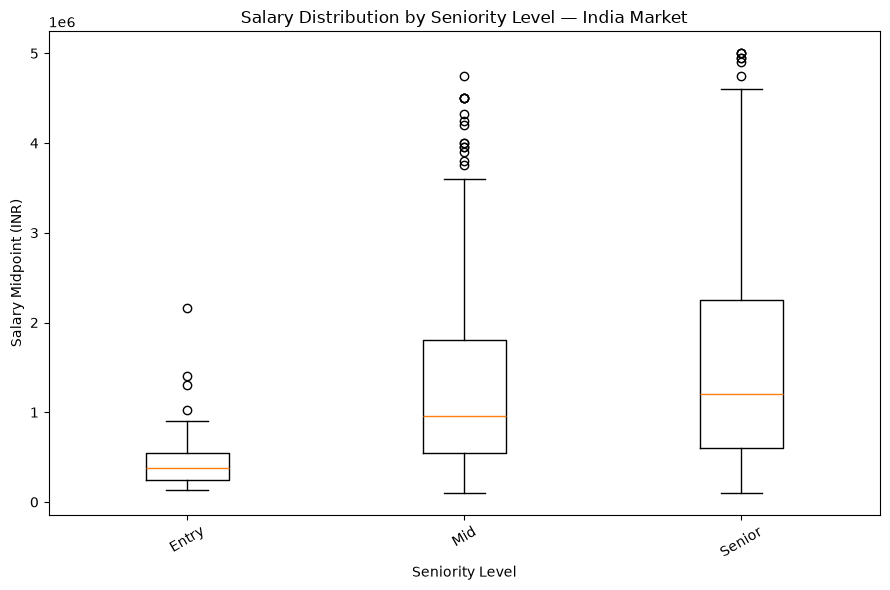

In [25]:
seniority_order = (
    salary_df.groupby("seniority_level")["salary_mid"]
    .median()
    .sort_values()
    .index
)

data = [
    salary_df.loc[
        salary_df["seniority_level"] == level,
        "salary_mid"
    ].dropna()
    for level in seniority_order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    data,
    tick_labels=list(seniority_order)
)

plt.title("Salary Distribution by Seniority Level — India Market")
plt.xlabel("Seniority Level")
plt.ylabel("Salary Midpoint (INR)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/10_salary_by_seniority.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.9 Salary vs Location

<Figure size 1000x700 with 0 Axes>

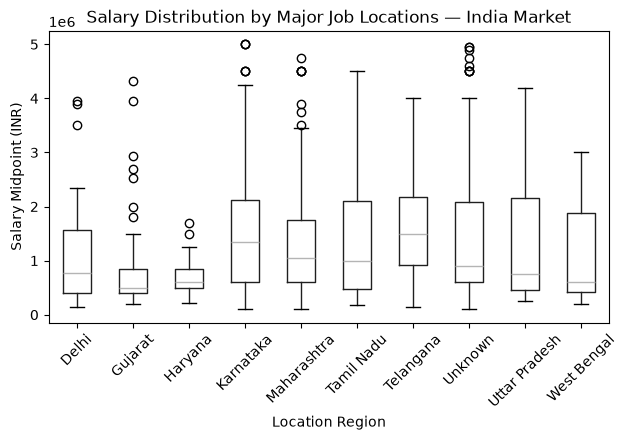

In [26]:
top_salary_regions = (
    salary_df["location_region"]
    .value_counts()
    .head(10)
    .index
)

region_salary_df = salary_df[
    salary_df["location_region"].isin(top_salary_regions)
]

plt.figure(figsize=(10, 7))

region_salary_df.boxplot(
    column="salary_mid",
    by="location_region",
    grid=False,
    rot=45
)

plt.title("Salary Distribution by Major Job Locations — India Market")
plt.suptitle("")
plt.xlabel("Location Region")
plt.ylabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/11_salary_by_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.10 Salary vs Job Category

<Figure size 1000x700 with 0 Axes>

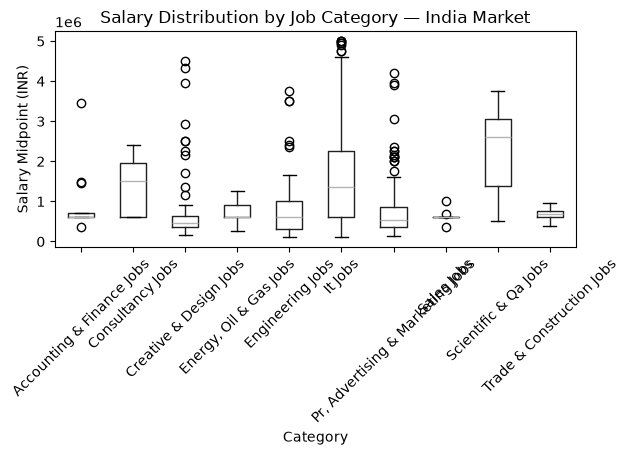

In [27]:
top_salary_categories = (
    salary_df["category_label"]
    .value_counts()
    .head(10)
    .index
)

category_salary_df = salary_df[
    salary_df["category_label"].isin(top_salary_categories)
]

plt.figure(figsize=(10, 7))

category_salary_df.boxplot(
    column="salary_mid",
    by="category_label",
    grid=False,
    rot=45
)

plt.title("Salary Distribution by Job Category — India Market")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/12_salary_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.11 Salary-Band Composition

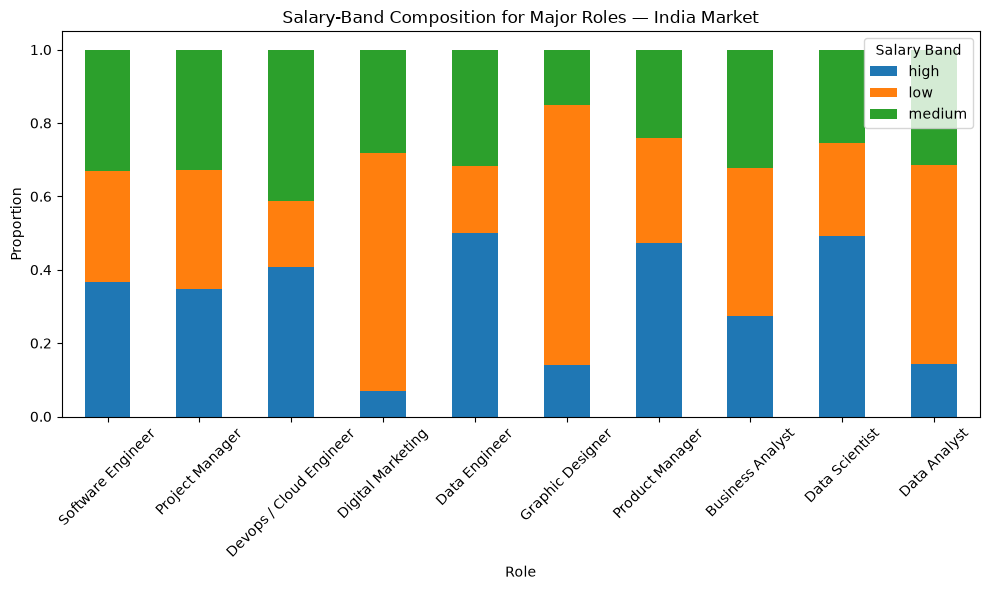

In [28]:
role_band = pd.crosstab(
    salary_df["role"],
    salary_df["salary_band"],
    normalize="index"
)

top_roles = salary_df["role"].value_counts().head(10).index

role_band.loc[top_roles].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Salary-Band Composition for Major Roles — India Market")
plt.xlabel("Role")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Salary Band")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/13_role_salary_band_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.12 Job Description Length

count    7240.000000
mean      497.646547
std        22.278141
min       112.000000
25%       500.000000
50%       500.000000
75%       500.000000
max       500.000000
Name: description_length, dtype: float64


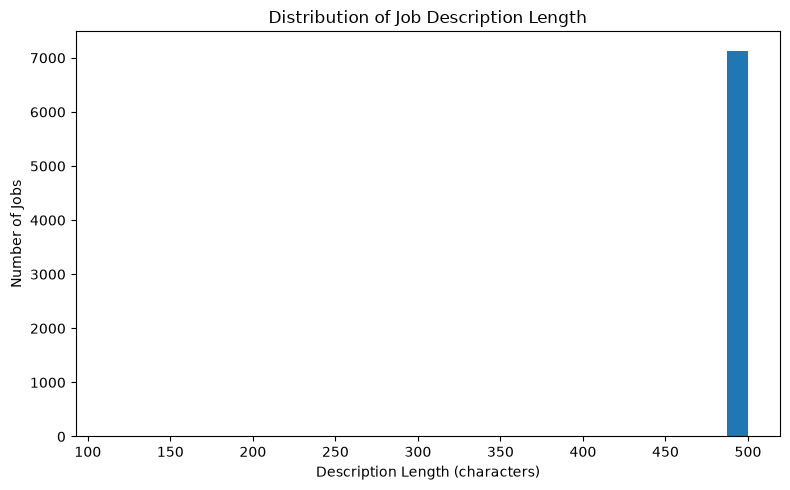

In [29]:
print(eda_df["description_length"].describe())

plt.figure(figsize=(8, 5))

plt.hist(
    eda_df["description_length"],
    bins=30
)

plt.title("Distribution of Job Description Length")
plt.xlabel("Description Length (characters)")
plt.ylabel("Number of Jobs")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/14_description_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.13 Common Terms in Job Descriptions

The cleaned descriptions are used for exploratory term-frequency analysis. This is descriptive text analysis only and does not perform feature engineering.

In [30]:
all_text = " ".join(
    eda_df["description_clean"]
    .dropna()
    .astype(str)
)

words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9+#.-]*\b", all_text.lower())

word_counts = Counter(words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["term", "count"]
)

display(top_words)

,term,count
0,business,3837
1,datum,3816
2,team,3804
3,role,3788
4,experience,3384
5,work,3175
6,product,2815
7,job,2721
8,s,2528
9,platform,2520


<Figure size 900x700 with 0 Axes>

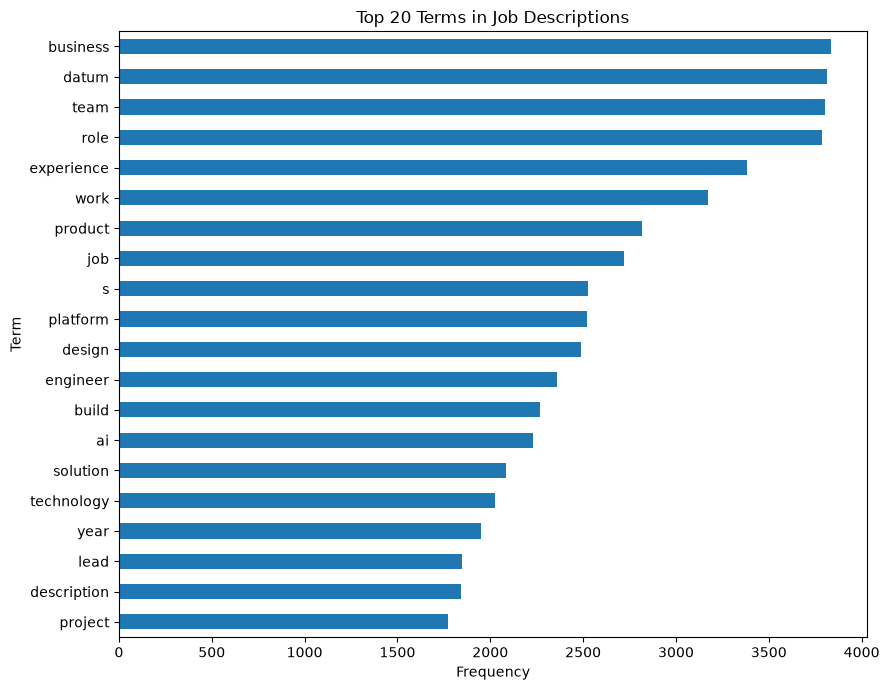

In [31]:
plt.figure(figsize=(9, 7))

top_words.sort_values("count").plot(
    x="term",
    y="count",
    kind="barh",
    legend=False,
    figsize=(9, 7)
)

plt.title("Top 20 Terms in Job Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/15_top_terms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.14 Skill Prevalence

Skill prevalence is estimated using keyword matching in `description_clean`. Since the preprocessing pipeline truncates job descriptions to 500 characters, these counts represent a lower-bound estimate of skill mentions in the original job postings.

In [32]:
skills = [
    "python",
    "sql",
    "excel",
    "power bi",
    "aws",
    "java",
    "communication"
]

skill_results = []

text = eda_df["description_clean"].fillna("").astype(str).str.lower()

for skill in skills:
    count = text.str.contains(
        rf"\b{re.escape(skill)}\b",
        regex=True
    ).sum()

    skill_results.append({
        "skill": skill,
        "job_count": count,
        "percentage": count / len(eda_df) * 100
    })

skill_df = pd.DataFrame(skill_results)

display(skill_df.round(2))

,skill,job_count,percentage
0,python,296,4.09
1,sql,290,4.01
2,excel,60,0.83
3,power bi,68,0.94
4,aws,135,1.86
5,java,99,1.37
6,communication,255,3.52


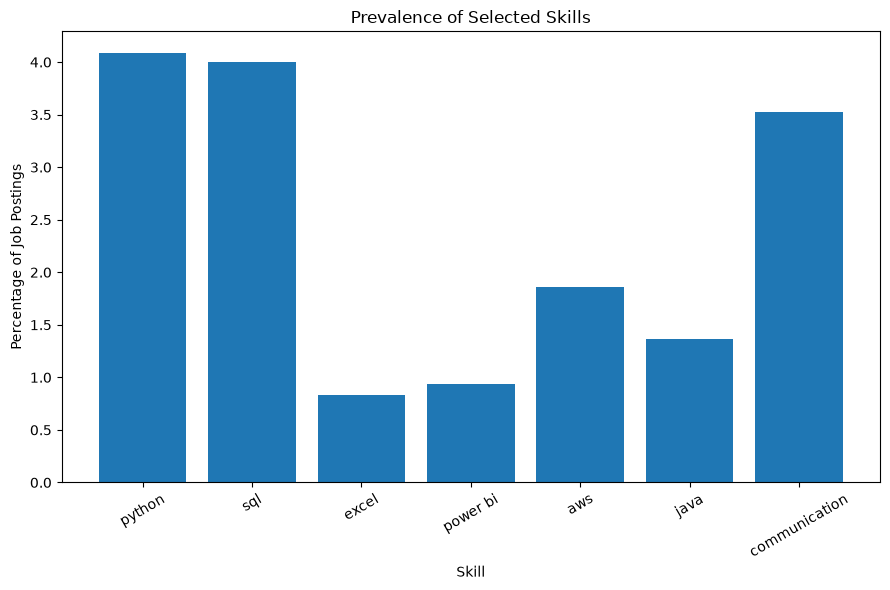

In [33]:
plt.figure(figsize=(9, 6))

plt.bar(
    skill_df["skill"],
    skill_df["percentage"]
)

plt.title("Prevalence of Selected Skills")
plt.xlabel("Skill")
plt.ylabel("Percentage of Job Postings")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/16_skill_prevalence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.15 Data Quality — Missing Values

In [34]:
missing = (
    eda_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

display(
    pd.DataFrame({
        "missing_count": missing,
        "missing_percentage": missing / len(eda_df) * 100
    }).round(2)
)

,missing_count,missing_percentage
salary_band,6087,84.07
salary_mid,6087,84.07
salary_max,5934,81.96
salary_min,5931,81.92
description_clean,3,0.04


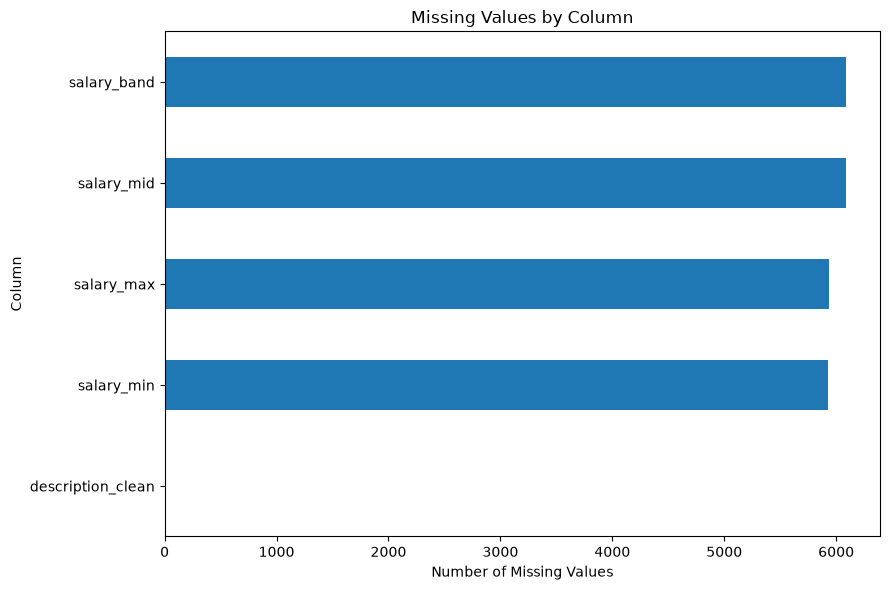

In [35]:
plt.figure(figsize=(9, 6))

missing.sort_values().plot(kind="barh")

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/17_missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.16 Salary Outlier Check

The IQR rule is used only to identify potentially extreme salary midpoint observations. These observations are not removed or modified during EDA.

In [36]:
q1 = salary_df["salary_mid"].quantile(0.25)
q3 = salary_df["salary_mid"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = salary_df[
    (salary_df["salary_mid"] < lower_bound) |
    (salary_df["salary_mid"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Potential salary outliers:", len(outliers))

Q1: 600000.0
Q3: 2000000.0
IQR: 1400000.0
Lower bound: -1500000.0
Upper bound: 4100000.0
Potential salary outliers: 27


## 2.17 Duplicate Job ID Check

In [37]:
duplicate_count = eda_df["job_id"].duplicated().sum()

print("Duplicate job IDs:", duplicate_count)

Duplicate job IDs: 0


## 2.18 Numeric Correlation

In [38]:
numeric_cols = [
    "salary_mid",
    "description_length"
]

correlation = eda_df[numeric_cols].corr()

display(correlation.round(3))

,salary_mid,description_length
salary_mid,1.000,-0.035
description_length,-0.035,1.000


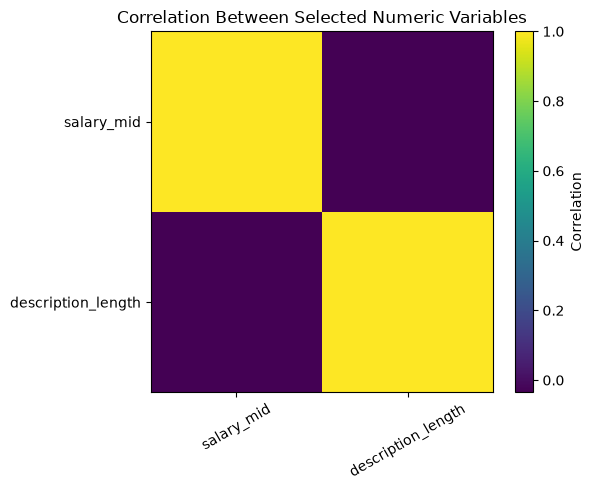

In [39]:
plt.figure(figsize=(6, 5))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=30
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Selected Numeric Variables")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/18_numeric_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# Data-driven salary summaries

print("=" * 60)
print("SALARY SUMMARY")
print("=" * 60)

# Overall salary statistics
print("\nOverall salary statistics:")
print(f"Median: ₹{salary_df['salary_mid'].median():,.0f}")
print(f"Q1:     ₹{salary_df['salary_mid'].quantile(0.25):,.0f}")
print(f"Q3:     ₹{salary_df['salary_mid'].quantile(0.75):,.0f}")


# Salary by role
role_salary_summary = (
    salary_df.groupby("role")["salary_mid"]
    .agg(["count", "median"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
)

print("\nSalary by role:")
display(role_salary_summary)


# Salary by seniority
seniority_salary_summary = (
    salary_df.groupby("seniority_level")["salary_mid"]
    .agg(["count", "median"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
)

print("\nSalary by seniority:")
display(seniority_salary_summary)


# Salary by region
region_salary_summary = (
    salary_df.groupby("location_region")["salary_mid"]
    .agg(["count", "median"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
)

print("\nSalary by region:")
display(region_salary_summary)

SALARY SUMMARY

Overall salary statistics:
Median: ₹1,000,000
Q1:     ₹600,000
Q3:     ₹2,000,000

Salary by role:


,count,median
role,,
Data Engineer,110,1650000.0
Data Scientist,75,1600000.0
Product Manager,91,1450000.0
Devops / Cloud Engineer,145,1400000.0
Software Engineer,218,1250000.0
Project Manager,153,1080000.0
Business Analyst,84,800000.0
Data Analyst,35,600000.0
Digital Marketing,142,500000.0



Salary by seniority:


,count,median
seniority_level,,
Senior,486,1200000.0
Mid,626,955000.0
Entry,41,375000.0



Salary by region:


,count,median
location_region,,
Telangana,63,1500000.0
Karnataka,275,1350000.0
Madhya Pradesh,12,1100000.0
Maharashtra,181,1050000.0
Tamil Nadu,61,1000000.0
Unknown,359,900000.0
Kerala,11,850000.0
Delhi,32,775000.0
Uttar Pradesh,26,750000.0


## 2.19 Key EDA Findings

- The dataset contains **7,184 job postings**, of which **1,101 have usable salary information** and are used for salary-related analysis.
- The salary target is distributed across **low (401), medium (337), and high (363)** salary bands, providing representation across all three classes.
- For salaried postings, the overall **median salary midpoint is ₹10.5 lakh**, with a first quartile of **₹6 lakh** and third quartile of **₹20 lakh**.
- Salary varies substantially across roles. Among roles with sufficient salary observations, **Data Engineer has the highest median salary at ₹16.5 lakh**, followed by Data Scientist at ₹15.95 lakh and Product Manager at ₹15 lakh.
- Salary also varies by seniority: **Senior roles have a median of ₹12.5 lakh**, compared with ₹9.8 lakh for Mid-level roles and ₹3.5 lakh for Entry-level roles.
- Regional salary differences are also visible. Among regions with at least 10 salary observations, **Telangana has a median of ₹15 lakh**, followed by Karnataka at ₹13.5 lakh and Tamil Nadu at ₹11.875 lakh.
- The selected skill-frequency analysis identifies mentions of **Python, SQL, Excel, Power BI, AWS, Java, and communication** across the job descriptions; these counts should be interpreted as lower-bound estimates because descriptions were truncated to approximately **500 characters** during preprocessing.
- Data-quality checks found **no duplicate `job_id` values**. Salary analysis is restricted to records with `has_salary == True`, while general market and text analysis uses the full dataset.

---
# 3. Feature Engineering

Build a leakage-free, interpretable feature matrix for the salary-band classifier using curated skill indicators and compact categorical features (role, seniority, location).

### 3.1 Build the curated feature matrix

Skill flags use the EDA-supported prevalence threshold (at least 1.5%). Locations outside the eight most common regions are grouped into `other`; `category_label` and `domain` are excluded because they are redundant with `role`.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

REQUIRED_FE_COLUMNS = {
    "has_salary", "salary_band", "description_clean", "role",
    "location_region", "contract_time", "seniority_level",
}
missing_fe_columns = sorted(REQUIRED_FE_COLUMNS.difference(df.columns))
if missing_fe_columns:
    raise KeyError(f"Missing required feature-engineering columns: {missing_fe_columns}")

SKILL_PATTERNS = {
    "python": r"(?<![a-z])python(?![a-z])",
    "sql": r"(?<![a-z])sql(?![a-z])",
    "communication": r"(?<![a-z])communication(?![a-z])",
    "azure": r"(?<![a-z])azure(?![a-z])",
    "machine_learning": r"(?<![a-z])machine[ _-]learning(?![a-z])",
    "agile": r"(?<![a-z])agile(?![a-z])",
    "aws": r"(?<![a-z])aws(?![a-z])",
    "linux": r"(?<![a-z])linux(?![a-z])",
    "java": r"(?<![a-z])java(?![a-z])",
    "sap": r"(?<![a-z])sap(?![a-z])",
    "docker": r"(?<![a-z])docker(?![a-z])",
}
TOP_REGIONS = [
    "Unknown", "Karnataka", "Maharashtra", "Telangana",
    "Tamil Nadu", "Gujarat", "Delhi", "Uttar Pradesh",
]
SENIORITY_MAP = {"Entry": 0, "Mid": 1, "Senior": 2}

model_df = df.loc[df["has_salary"].eq(True)].copy()
model_df = model_df.loc[model_df["salary_band"].notna()].copy()
if model_df.empty:
    raise ValueError("No labelled rows remain after filtering has_salary and salary_band.")

descriptions = model_df["description_clean"].fillna("").astype(str).str.lower()
skill_columns = []
for skill, pattern in SKILL_PATTERNS.items():
    column = f"skill_{skill}"
    model_df[column] = descriptions.str.contains(pattern, regex=True, na=False).astype("int8")
    skill_columns.append(column)
model_df["skill_count"] = model_df[skill_columns].sum(axis=1).astype("int8")

model_df["seniority_ordinal"] = model_df["seniority_level"].map(SENIORITY_MAP).fillna(1).astype("int8")
model_df["location_bucket"] = model_df["location_region"].where(model_df["location_region"].isin(TOP_REGIONS), "other")
model_df["is_full_time"] = model_df["contract_time"].eq("full_time").astype("int8")

categorical = pd.get_dummies(model_df[["role", "location_bucket"]].fillna("Unknown"), columns=["role", "location_bucket"], drop_first=True, dtype="int8")
numeric = model_df[["skill_count", "seniority_ordinal"]].astype("float64")
X = pd.concat([model_df[skill_columns], categorical, model_df[["is_full_time"]], numeric], axis=1).astype("float64")
y = model_df["salary_band"].astype(str)

forbidden_features = {"salary_min", "salary_max", "salary_mid", "salary_band", "salary_present", "salary_passes_plausibility_screen", "has_salary", "job_id", "title", "employer", "description_raw", "description_length", "domain"}
leakage_columns = sorted(forbidden_features.intersection(X.columns))
if leakage_columns:
    raise AssertionError(f"Salary leakage or excluded columns found in X: {leakage_columns}")
if X.isna().any().any() or y.isna().any():
    raise AssertionError("Feature matrix and target must not contain missing values.")

print(f"Feature matrix: {X.shape[1]} features")
print("Target distribution:")
display(y.value_counts(normalize=True).round(3).rename_axis("salary_band").to_frame("proportion"))

Feature matrix: 31 features
Target distribution:


,proportion
salary_band,
low,0.367
high,0.329
medium,0.304


### 3.2 Split first, then scale (and dimensionality-reduction decision)

The split is stratified and reproducible. Numeric features (`skill_count` and `seniority_ordinal`) are standardized using training rows only; binary indicators and one-hot columns remain unchanged. No PCA or TruncatedSVD is used because this curated matrix is small and dense enough to remain interpretable. If a future TF-IDF experiment is added, fit `TruncatedSVD` on `X_train` only and transform `X_test` with that fitted reducer.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
numeric_feature_columns = ["skill_count", "seniority_ordinal"]
X_train[numeric_feature_columns] = scaler.fit_transform(X_train[numeric_feature_columns])
X_test[numeric_feature_columns] = scaler.transform(X_test[numeric_feature_columns])

assert list(X_train.columns) == list(X_test.columns) == list(X.columns)
assert not X_train.isna().any().any() and not X_test.isna().any().any()
assert set(y_train) == set(y_test) == set(y)
print("Dimensionality reduction: not applied (curated feature matrix).")
print("Section 4 hand-off: X_train, X_test, y_train, y_test, feature_columns, scaler")

Dimensionality reduction: not applied (curated feature matrix).
Section 4 hand-off: X_train, X_test, y_train, y_test, feature_columns, scaler


In [43]:
feature_columns = X.columns.tolist()
print("Features:")
print(feature_columns)

Features:
['skill_python', 'skill_sql', 'skill_communication', 'skill_azure', 'skill_machine_learning', 'skill_agile', 'skill_aws', 'skill_linux', 'skill_java', 'skill_sap', 'skill_docker', 'role_Data Analyst', 'role_Data Engineer', 'role_Data Scientist', 'role_Devops / Cloud Engineer', 'role_Digital Marketing', 'role_Graphic Designer', 'role_Product Manager', 'role_Project Manager', 'role_Software Engineer', 'location_bucket_Gujarat', 'location_bucket_Karnataka', 'location_bucket_Maharashtra', 'location_bucket_Tamil Nadu', 'location_bucket_Telangana', 'location_bucket_Unknown', 'location_bucket_Uttar Pradesh', 'location_bucket_other', 'is_full_time', 'skill_count', 'seniority_ordinal']


---
# 4. Predictive Modelling

Train and tune salary-band classifiers (Logistic Regression and Random Forest) with stratified cross-validation, select the best, and additionally train a binary above/below-median model.

## 4.1 Baseline — the bar to beat

The majority-class baseline is what a model that always predicts the most common band would score. Any real model must clearly beat it.

In [44]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# leakage-safe baseline: majority class proportion on the training labels
baseline_acc = y_train.value_counts(normalize=True).max()
print(f"Majority-class baseline (train): {baseline_acc:.3f}  (~{baseline_acc*100:.1f}%)")
print(f"Random-guess (3 balanced classes): ~0.333")

Majority-class baseline (train): 0.367  (~36.7%)
Random-guess (3 balanced classes): ~0.333


## 4.2 Candidate models + cross-validated tuning

Two interpretable, small-sample-safe models, tuned with 5-fold stratified CV on **macro-F1** (all three bands matter equally). Only the training set is used here — the test set stays untouched.

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    "LogisticRegression": (
        LogisticRegression(max_iter=2000, random_state=42),
        {"C": [0.1, 1.0, 10.0]},
    ),
    "RandomForest": (
        RandomForestClassifier(n_estimators=300, random_state=42),
        {"max_depth": [5, 8, 12], "min_samples_leaf": [1, 5]},
    ),
}

searches, cv_scores = {}, {}
for name, (estimator, grid) in search_spaces.items():
    gs = GridSearchCV(estimator, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    cv_scores[name] = gs.best_score_
    print(f"{name:20s} best CV macro-F1 = {gs.best_score_:.3f}  params={gs.best_params_}")

LogisticRegression   best CV macro-F1 = 0.462  params={'C': 1.0}


RandomForest         best CV macro-F1 = 0.507  params={'max_depth': 8, 'min_samples_leaf': 1}


## 4.3 Select and refit the final model

Pick the model with the best cross-validated macro-F1. `GridSearchCV` has already refit it on the full training set.

In [46]:
best_name = max(cv_scores, key=cv_scores.get)
final_model = searches[best_name].best_estimator_

# quick sanity: CV accuracy of the chosen model vs baseline (train only)
cv_acc = cross_val_score(final_model, X_train, y_train, cv=cv, scoring="accuracy").mean()
print(f"Selected model : {best_name}")
print(f"CV macro-F1    : {cv_scores[best_name]:.3f}")
print(f"CV accuracy    : {cv_acc:.3f}  (baseline {baseline_acc:.3f})")
print(f"Lift over baseline: +{(cv_acc - baseline_acc)*100:.1f} points")
print("\nHand-off to Section 5: final_model, X_test, y_test, feature_columns, scaler, baseline_acc")

Selected model : RandomForest
CV macro-F1    : 0.507
CV accuracy    : 0.524  (baseline 0.367)
Lift over baseline: +15.7 points

Hand-off to Section 5: final_model, X_test, y_test, feature_columns, scaler, baseline_acc


## 4.4 Save the model for the dashboard

Persist the model + scaler + feature order + skill list together so `dashboard/app.py` can rebuild the exact 31-feature vector from the user's selections.

In [47]:
import os
import joblib

SKILLS = ["python", "sql", "communication", "azure", "machine_learning",
          "agile", "aws", "linux", "java", "sap", "docker"]

os.makedirs("../models", exist_ok=True)
artifact = {
    "model": final_model,
    "scaler": scaler,
    "feature_columns": feature_columns,
    "numeric_cols": ["skill_count", "seniority_ordinal"],
    "skills": SKILLS,
    "classes": sorted(final_model.classes_.tolist()),
    "baseline_accuracy": float(baseline_acc),
    "model_name": best_name,
}
joblib.dump(artifact, "../models/salary_band_model.joblib")
print("Saved -> models/salary_band_model.joblib")
print("classes:", artifact["classes"])
print("n_features:", len(feature_columns))

Saved -> models/salary_band_model.joblib
classes: ['high', 'low', 'medium']
n_features: 31


## 4.5 Binary model — above / below median salary

A higher-confidence view that predicts whether a posting pays above or below the market median, trained on the same features.

In [48]:
median_salary = model_df["salary_mid"].median()
y_binary = (model_df["salary_mid"] >= median_salary).map({True: "above", False: "below"})

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, y_binary, test_size=0.20, stratify=y_binary, random_state=42)
binary_scaler = StandardScaler().fit(Xb_train[["skill_count", "seniority_ordinal"]])
Xb_train = Xb_train.copy(); Xb_test = Xb_test.copy()
Xb_train[["skill_count", "seniority_ordinal"]] = binary_scaler.transform(Xb_train[["skill_count", "seniority_ordinal"]])
Xb_test[["skill_count", "seniority_ordinal"]] = binary_scaler.transform(Xb_test[["skill_count", "seniority_ordinal"]])

binary_searches, binary_scores = {}, {}
for name, (estimator, grid) in search_spaces.items():
    gs = GridSearchCV(estimator, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(Xb_train, yb_train)
    binary_searches[name] = gs
    binary_scores[name] = gs.best_score_

binary_best = max(binary_scores, key=binary_scores.get)
binary_model = binary_searches[binary_best].best_estimator_
binary_cv_acc = cross_val_score(binary_model, Xb_train, yb_train, cv=cv, scoring="accuracy").mean()
print(f"Binary model   : {binary_best}")
print(f"CV accuracy    : {binary_cv_acc:.3f}  (above/below median)")

Binary model   : RandomForest
CV accuracy    : 0.682  (above/below median)


In [49]:
joblib.dump(
    {"model": binary_model, "scaler": binary_scaler, "feature_columns": feature_columns,
     "numeric_cols": ["skill_count", "seniority_ordinal"], "skills": SKILLS,
     "classes": sorted(binary_model.classes_.tolist()),
     "median_salary": float(median_salary), "model_name": binary_best},
    "../models/salary_binary_model.joblib")
print("Saved -> models/salary_binary_model.joblib")

Saved -> models/salary_binary_model.joblib


## 4.6 Text-enhanced models

Adds job-title and description word features (TF-IDF) to the structured features. Performance is validated with employer-grouped cross-validation, so a company never appears in both training and validation. This gives a realistic estimate for postings from unseen employers.

In [3]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

text_df = model_df.reset_index(drop=True)
X_struct = csr_matrix(X.reset_index(drop=True).values)

title_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=300)
desc_vec = TfidfVectorizer(min_df=5, max_features=500, stop_words="english")
X_title = title_vec.fit_transform(text_df["title"].fillna("").str.lower())
X_desc = desc_vec.fit_transform(text_df["description_clean"].fillna(""))
X_text = hstack([X_struct, X_title, X_desc]).tocsr()

employer_groups = text_df["employer"].fillna("unknown").str.lower().str.strip()
y_band_text = text_df["salary_band"].astype(str)
median_text = text_df["salary_mid"].median()
y_binary_text = (text_df["salary_mid"] >= median_text).map({True: "above", False: "below"})

grouped_cv = GroupKFold(n_splits=5)
text_rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=1)

rows = {}
for label, features in [("Structured features", X_struct), ("Structured + title + description", X_text)]:
    rows[label] = {
        "Band accuracy": cross_val_score(text_rf, features, y_band_text, cv=grouped_cv, groups=employer_groups, scoring="accuracy").mean(),
        "Binary accuracy": cross_val_score(text_rf, features, y_binary_text, cv=grouped_cv, groups=employer_groups, scoring="accuracy").mean(),
    }
display(pd.DataFrame(rows).T.round(3).rename_axis("Feature set"))

,Band accuracy,Binary accuracy
Feature set,,
Structured features,0.483,0.691
Structured + title + description,0.492,0.712


In [4]:
import joblib

text_band_model = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=1).fit(X_text, y_band_text)
text_binary_model = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=1).fit(X_text, y_binary_text)

joblib.dump(
    {"band_model": text_band_model, "binary_model": text_binary_model,
     "title_vectorizer": title_vec, "description_vectorizer": desc_vec,
     "feature_columns": X.columns.tolist(), "median_salary": float(median_text)},
    "../models/salary_text_models.joblib")
print("Saved -> models/salary_text_models.joblib")

Saved -> models/salary_text_models.joblib


---
# 5. Evaluation & Business Interpretation

Report model performance, the confusion matrix, feature importance (what drives pay) and the business takeaways for the Indian job market.

Loading data...


\n--- Evaluating Tuned Binary Model ---


Accuracy: 0.6580 | F1-Score: 0.6572


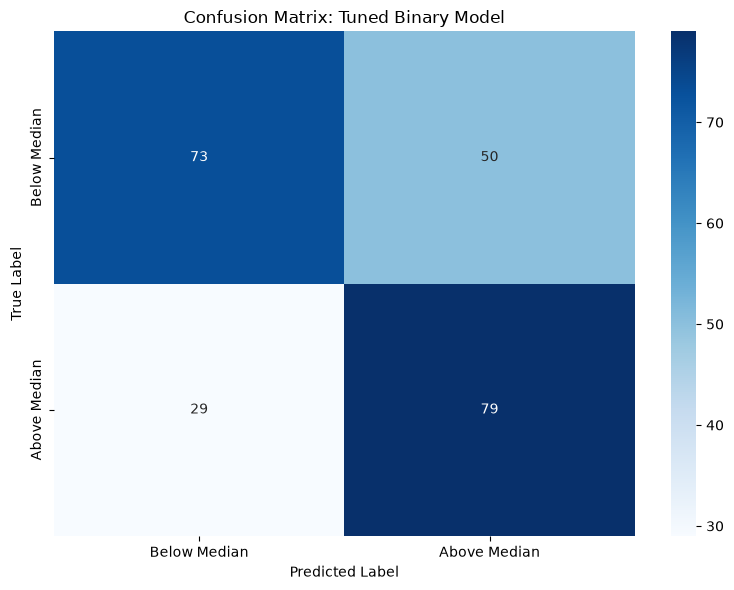

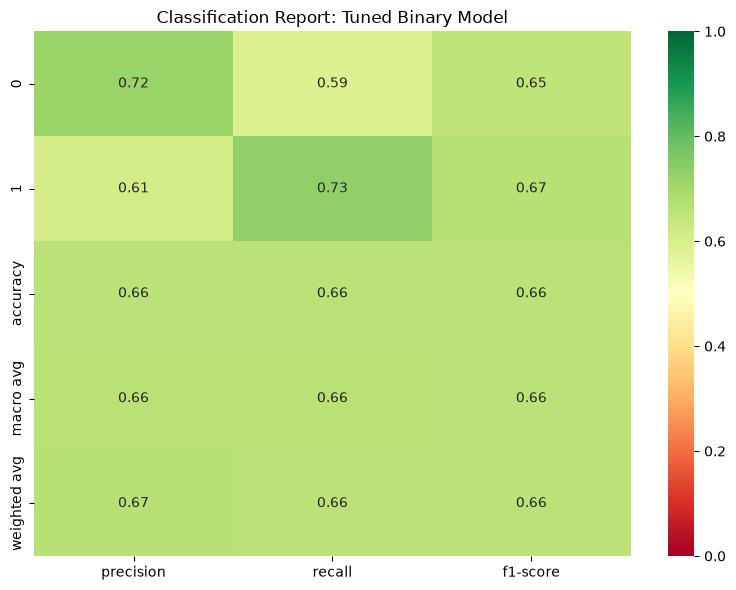

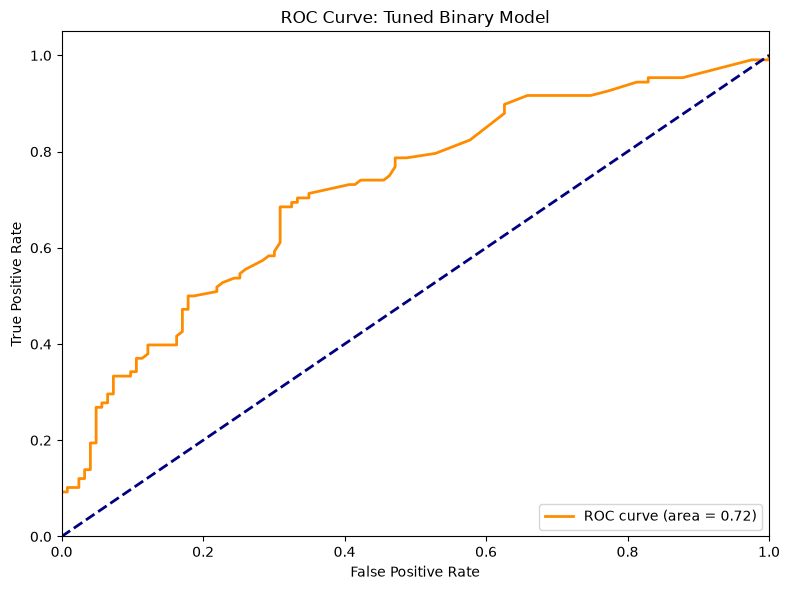

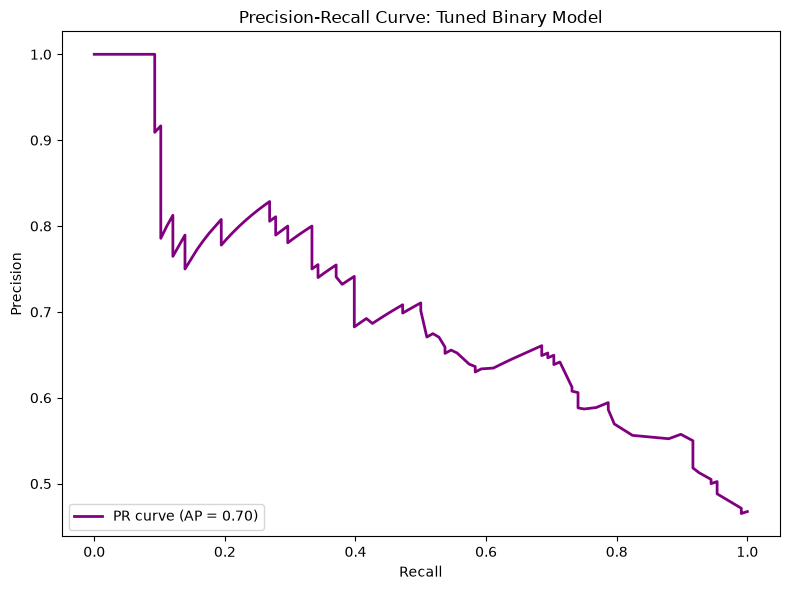

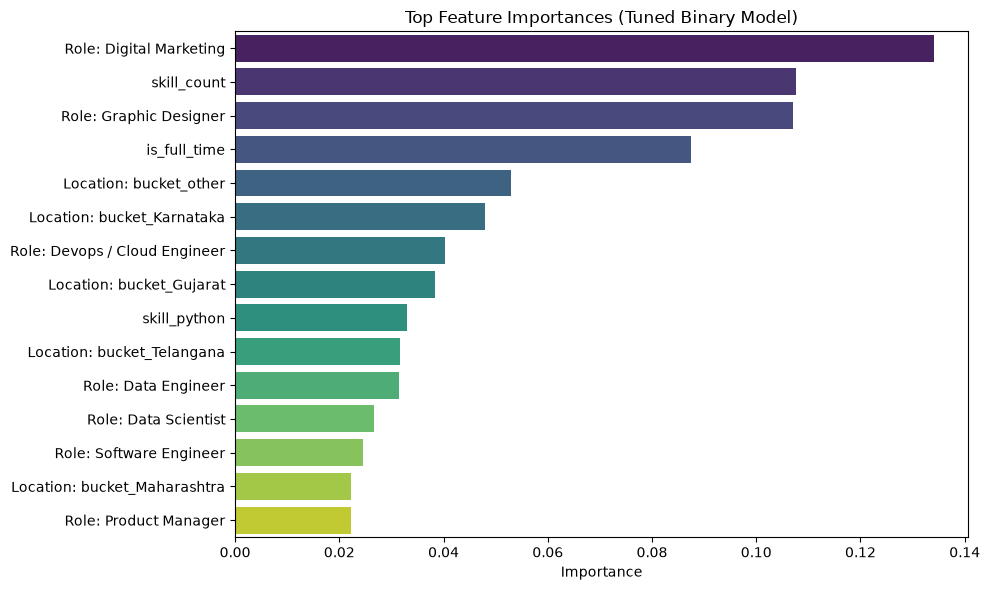

\n--- Evaluating Salary Band Model ---


Accuracy: 0.5108 | F1-Score: 0.4344


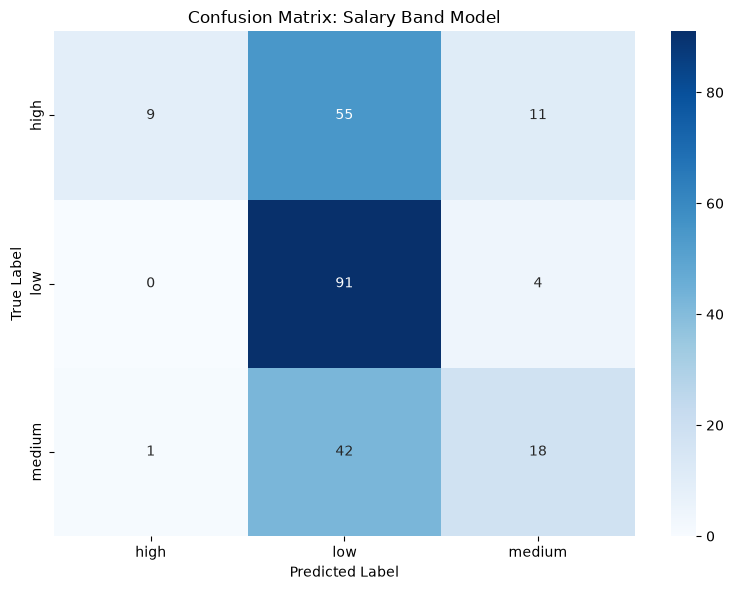

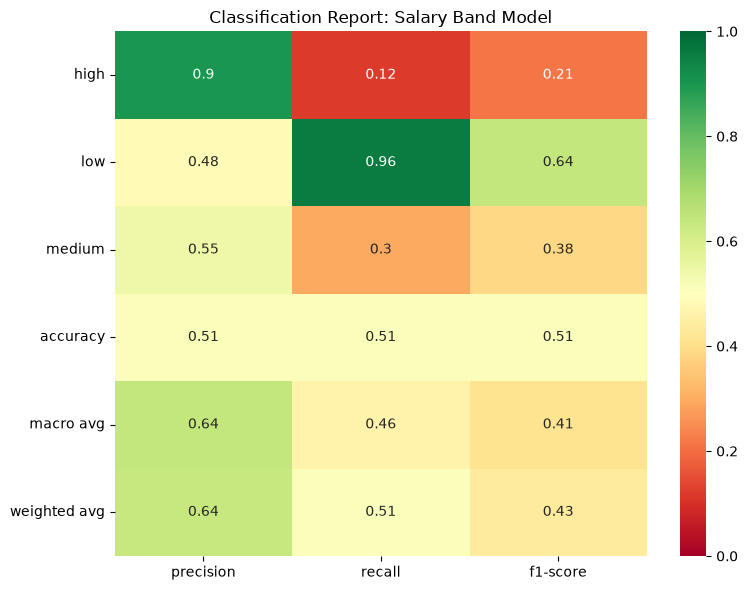

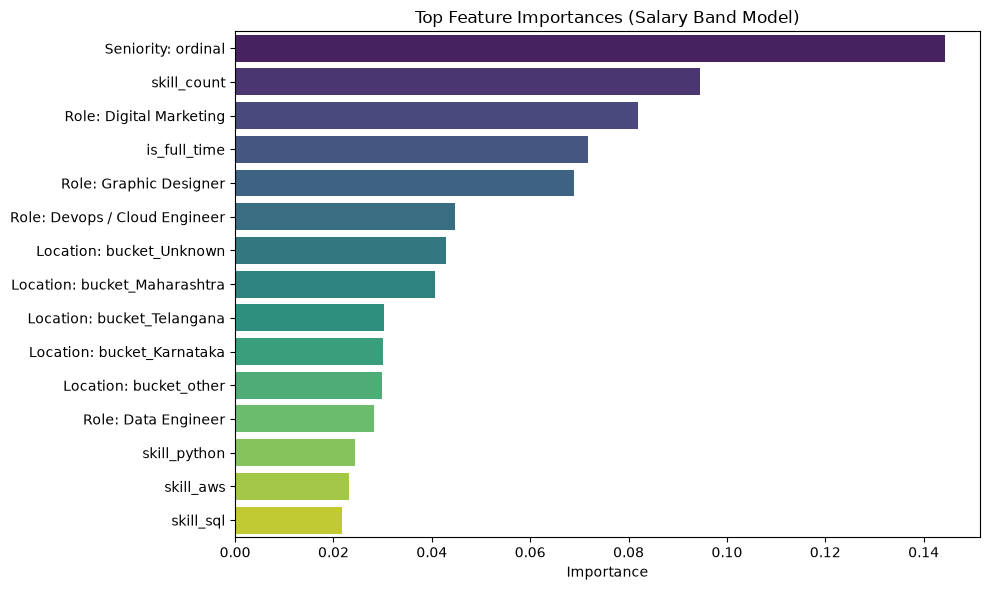

In [50]:

import os
import sys

# Move to project root so the script can find 'data/' and 'models/' directories
os.chdir('..') 
sys.path.append('./scripts')

# Run the comprehensive evaluation and display plots
from evaluate_models import evaluate_models
evaluate_models()

# Revert back to notebooks directory
os.chdir('notebooks')
